# GTFS Public Transport Dataset

The main dataset is the GTFS timetable dataset provided by Swiss Federal Railways via OpenTransportData. It contains the complete public transport schedule for Switzerland.

Dataset: https://data.opentransportdata.swiss/fr/dataset/timetable-2026-gtfs2020

Description of the dataset: https://opentransportdata.swiss/fr/cookbook/timetable-cookbook/gtfs/

## Structure : 

The dataset is composed of multiple CSV files describing different aspects of the network, including:
- `stops.txt` : geographic coordinates of stops and stations
- `routes.txt`: transport lines and operators
- `trips.txt`: individual vehicle trips
- `stop_times.txt`: schedule of arrivals and departures
- `transfers.txt`: transfer times between stops
- `calendar.txt`: service availability by date

In [1]:
import requests
from pathlib import Path
import zipfile
import pandas as pd
import matplotlib.pyplot as plt

# Configuration of paths
URL = "https://data.opentransportdata.swiss/fr/dataset/timetable-2026-gtfs2020/permalink"
GTFS_DIR = Path("data/gtfs")
ZIP_FILE = GTFS_DIR / "gtfs_fp2026.zip"

# Create the directory if it doesn't exist
GTFS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Download the ZIP file if it's not already present
if not ZIP_FILE.exists():
    print(f"Downloading GTFS data to {ZIP_FILE}...")
    # Stream the download to handle large files efficiently
    r = requests.get(URL, stream=True)
    r.raise_for_status() 
    with open(ZIP_FILE, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)

In [3]:
# Extracting all files directly into data/gtfs/
with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
    zip_ref.extractall(GTFS_DIR)
    print(f"Files extracted to {GTFS_DIR}")

Files extracted to data/gtfs


In [4]:
# Loading the DataFrames
stops = pd.read_csv(GTFS_DIR / "stops.txt")
routes = pd.read_csv(GTFS_DIR / "routes.txt")
trips = pd.read_csv(GTFS_DIR / "trips.txt")
stop_times = pd.read_csv(GTFS_DIR / "stop_times.txt")
transfers = pd.read_csv(GTFS_DIR / "transfers.txt")
calendar = pd.read_csv(GTFS_DIR / "calendar.txt")

/var/folders/dg/jjw_9gyd1p38f4_jp_6s89r00000gn/T/ipykernel_28024/2367158564.py:2: DtypeWarning: Columns (5,6) have mixed types. Specify dtype option on import or set low_memory=False.
  stops = pd.read_csv(GTFS_DIR / "stops.txt")


In [5]:
print("Stops:", stops.shape)
print("Routes:", routes.shape)
print("Trips:", trips.shape)
print("Stop times:", stop_times.shape)
print("Transfers:", transfers.shape)
print("Calendar:", calendar.shape)

Stops: (96949, 8)
Routes: (4840, 6)
Trips: (1161408, 9)
Stop times: (18671882, 7)
Transfers: (211319, 8)
Calendar: (41276, 10)


## Stops

In [6]:
stops.head()

,stop_id,stop_name,stop_lat,stop_lon,location_type,parent_station,platform_code,original_stop_id
0,1100008,"Zell (Wiesental), Wilder Mann",47.710084,7.859648,NaN,Parent1100008,NaN,ch:1:sloid:1100008
1,1100009,"Zell (Wiesental), Grönland",47.713191,7.862909,NaN,Parent1100009,NaN,ch:1:sloid:1100009
2,1100010,Atzenbach,47.714618,7.872350,NaN,Parent1100010,NaN,ch:1:sloid:1100010
3,1100011,"Mambach, Brücke",47.728209,7.877470,NaN,Parent1100011,NaN,ch:1:sloid:1100011
4,1100012,"Mambach, Mühlschau",47.734082,7.881387,NaN,Parent1100012,NaN,ch:1:sloid:1100012


The `stops` dataframe contains information about all the stops in the GTFS feed, including:
- `stop_id`: unique identifier for the stop
- `stop_name`: name of the stop
- `stop_lat` and `stop_lon`: geographic coordinates of the stop
- `location_type`: indicates if it's a stop (0) or a station (1)
- `parent_station`: if it's a stop that belongs to a station, this field contains the `stop_id` of the parent station
- `platform_code`: code for the platform (if applicable)
- `original_stop_id`: the original stop ID from the source data (if different from `stop_id`)

We keep only the relevant columns for our analysis: `stop_id`, `stop_name`, `stop_lat`, `stop_lon`, and `parent_station`.


In [7]:
# Keeping only the relevant columns for our analysis
stops = stops[['stop_id', 'stop_name', 'stop_lat', 'stop_lon', 'parent_station']]
stops.head()

,stop_id,stop_name,stop_lat,stop_lon,parent_station
0,1100008,"Zell (Wiesental), Wilder Mann",47.710084,7.859648,Parent1100008
1,1100009,"Zell (Wiesental), Grönland",47.713191,7.862909,Parent1100009
2,1100010,Atzenbach,47.714618,7.872350,Parent1100010
3,1100011,"Mambach, Brücke",47.728209,7.877470,Parent1100011
4,1100012,"Mambach, Mühlschau",47.734082,7.881387,Parent1100012


### Total Number of Stops in Switzerland

Stops correspond to stations, bus stops, tram stops, ...

In [8]:
total_stops = stops["stop_id"].nunique()
print("Total number of stops:", total_stops)

Total number of stops: 96949


## Routes

In [9]:
routes.head()

,route_id,agency_id,route_short_name,route_long_name,route_desc,route_type
0,91-10-A-j26-1,78,S10,NaN,S,109
1,91-10-B-j26-1,11,S10,NaN,S,109
2,91-10-C-j26-1,65,S10,NaN,S,109
3,91-10-D-j26-1,11,10,NaN,EXT,117
4,91-10-E-j26-1,3849,10,NaN,T,900


The `routes` dataframe contains information about the different routes in the GTFS feed, including:
 - `route_id`: unique identifier for each route
 - `agency_id`: identifier for the agency that operates the route
 - `route_short_name`: short name or number of the route (e.g., "S10", "IC", "IR46")
 - `route_long_name`: full name of the route (always empty in this dataset)
 - `route_desc`: description of the route (e.g., "S", "IC", "IR")
 - `route_type`: numeric code representing the route_desc

 We keep only the relevant columns for our analysis: `route_id`, `route_desc` (renamed `route_category`) and we map `route_type` (renamed `route_mode`) into the English name of the transportation mode as following:

In [10]:
# Keeping only the relevant columns for our analysis and mapping route_type to human-readable categories
routes = routes[['route_id', 'route_desc', 'route_type']]
route_type_map = {
    0: "Tram",
    1: "Metro",
    2: "Train",
    3: "Bus",
    4: "Ferry/Boat",
    5: "Cable car",
    6: "Cable car",
    7: "Funicular",

    700: "Bus",
    702: "Bus",
    705: "Bus",
    710: "Bus",
    715: "Bus",
    201: "Bus",
    202: "Bus",

    900: "Tram",
    401: "Metro",

    100: "Train",
    101: "Train",
    102: "Train",
    103: "Train",
    104: "Train",
    105: "Train",
    106: "Train",
    107: "Train",
    109: "Train",
    116: "Train",
    117: "Train",

    1000: "Ferry/Boat",

    1100: "Airplane",

    1300: "Cable car",
    1303: "Elevator",

    1400: "Funicular",

    1500: "Taxi",
    1700: "Unknown",
}

routes["route_mode"] = routes["route_type"].map(route_type_map).fillna("Other")
routes = routes[["route_id", "route_desc", "route_mode"]].rename(columns={"route_desc": "route_category"})
routes.head()

,route_id,route_category,route_mode
0,91-10-A-j26-1,S,Train
1,91-10-B-j26-1,S,Train
2,91-10-C-j26-1,S,Train
3,91-10-D-j26-1,EXT,Train
4,91-10-E-j26-1,T,Tram


### Distribution of Transport Modes

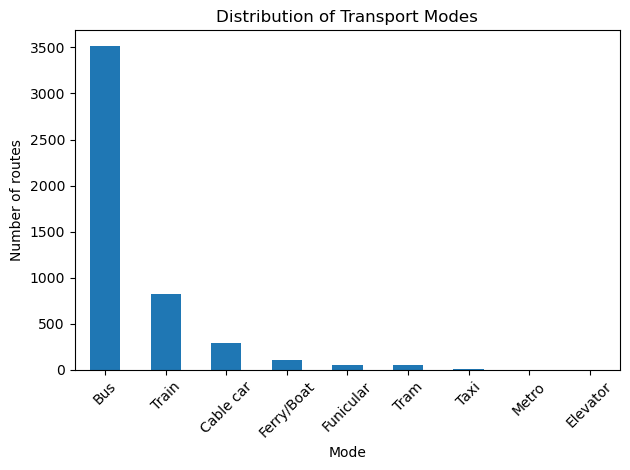

In [11]:
# Count routes by mode and plot the distribution
mode_counts = routes["route_mode"].value_counts().sort_values(ascending=False)

mode_counts.plot(kind="bar")
plt.title("Distribution of Transport Modes")
plt.xlabel("Mode")
plt.ylabel("Number of routes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Trips

In [12]:
trips.head()

,route_id,service_id,trip_id,trip_headsign,trip_short_name,direction_id,block_id,original_trip_id,hints
0,91-10-A-j26-1,TA+lbs00,1.TA.91-10-A-j26-1.1.H,Zürich HB,12902,0,NaN,ch:1:sjyid:100058:12902-001,2 NF VN
1,91-10-A-j26-1,TA+lbs00,10.TA.91-10-A-j26-1.1.H,Zürich HB,12774,0,NaN,ch:1:sjyid:100058:12774-001,2 NF VN
2,91-10-A-j26-1,TA+ral00,100.TA.91-10-A-j26-1.5.H,Zürich Selnau,12808,0,NaN,ch:1:sjyid:100058:12808-002,2 NF
3,91-10-A-j26-1,TA+ral00,101.TA.91-10-A-j26-1.5.H,Zürich Selnau,12916,0,NaN,ch:1:sjyid:100058:12916-002,2 NF
4,91-10-A-j26-1,TA+ral00,102.TA.91-10-A-j26-1.5.H,Zürich Selnau,12920,0,NaN,ch:1:sjyid:100058:12920-003,2 NF


The `trips` dataframe contains information about individual trips, including:
- `route_id`: identifier linking the trip to a route
- `service_id`: identifier linking the trip to a service schedule
- `trip_id`: unique identifier for each trip
- `trip_headsign`: text displayed to passengers (e.g., "Milano Centrale")
- `trip_short_name`: for trains, this field contains the train number
- `direction_id`: indicates the direction of the trip (0 or 1)
- `block_id`: used to identify which trips are operated by the same vehicle
- `original_trip_id`: Swiss Journey ID (SJYID)
- `hints`: specific traffic notes based on Swiss customer information standards

We keep only the relevant columns for our analysis: `route_id`, `service_id`, `trip_id`, `trip_headsign`, and `direction_id`.

In [13]:
# Keeping only the relevant columns for our analysis
trips = trips[["route_id", "service_id", "trip_id", "trip_headsign", "direction_id"]]
trips.head()

,route_id,service_id,trip_id,trip_headsign,direction_id
0,91-10-A-j26-1,TA+lbs00,1.TA.91-10-A-j26-1.1.H,Zürich HB,0
1,91-10-A-j26-1,TA+lbs00,10.TA.91-10-A-j26-1.1.H,Zürich HB,0
2,91-10-A-j26-1,TA+ral00,100.TA.91-10-A-j26-1.5.H,Zürich Selnau,0
3,91-10-A-j26-1,TA+ral00,101.TA.91-10-A-j26-1.5.H,Zürich Selnau,0
4,91-10-A-j26-1,TA+ral00,102.TA.91-10-A-j26-1.5.H,Zürich Selnau,0


### Distribution of Trips per Route

We count how many unique trip_ids are associated with each route_id.

This counts EVERY planned trip over the entire duration of the GTFS feed (which span an entire year).

This is a measure of "Network Volume" rather than "Daily Frequency."

To get the frequency for a specific day, we would need to filter by a specific 'service_id' first.

In [14]:
trips_per_route = trips.groupby("route_id")["trip_id"].count()
print("Statistical summary of trips per route (for a year):")
print(trips_per_route.describe())

Statistical summary of trips per route (for a year):
count     4840.000000
mean       239.960331
std        877.807960
min          1.000000
25%         14.000000
50%         49.000000
75%        148.000000
max      26722.000000
Name: trip_id, dtype: float64


## Stop times

In [16]:
stop_times.head()

,trip_id,arrival_time,departure_time,stop_id,stop_sequence,pickup_type,drop_off_type
0,1.TA.91-10-A-j26-1.1.H,18:07:00,18:07:00,8503054:0:1,1,0,0
1,1.TA.91-10-A-j26-1.1.H,18:08:00,18:08:00,8503053:0:1,2,0,0
2,1.TA.91-10-A-j26-1.1.H,18:09:00,18:09:00,8503052:0:1,3,0,0
3,1.TA.91-10-A-j26-1.1.H,18:12:00,18:12:00,8503051:0:1,4,0,0
4,1.TA.91-10-A-j26-1.1.H,18:15:00,18:15:00,8503090:0:1,5,0,0


The stop_times dataframe contains information about the scheduled times for each trip at each stop, including:
- `trip_id`: unique identifier for each trip
- `arrival_time`: scheduled arrival time at the stop (in HH:MM:SS format, can be >24:00:00 for trips that go past midnight)
- `departure_time`: scheduled departure time from the stop (in HH:MM:SS format, can be >24:00:00 for trips that go past midnight)
- `stop_id`: unique identifier for each stop
- `stop_sequence`: the order of stops for a given trip (starting at 1 for the first stop)
- `pickup_type` and `drop_off_type`: indicate whether passengers can board or alight at the stop (0 = regular, 1 = no pickup/drop-off, 2 = phone agency, 3 = coordinate with driver)

We keep only the relevant columns for our analysis and convert the arrival and departure times to datetime objects for easier analysis.

In [17]:
# Keeping only the relevant columns for our analysis
stop_times = stop_times[["trip_id", "arrival_time", "departure_time", "stop_id", "stop_sequence"]]
stop_times.head()

,trip_id,arrival_time,departure_time,stop_id,stop_sequence
0,1.TA.91-10-A-j26-1.1.H,18:07:00,18:07:00,8503054:0:1,1
1,1.TA.91-10-A-j26-1.1.H,18:08:00,18:08:00,8503053:0:1,2
2,1.TA.91-10-A-j26-1.1.H,18:09:00,18:09:00,8503052:0:1,3
3,1.TA.91-10-A-j26-1.1.H,18:12:00,18:12:00,8503051:0:1,4
4,1.TA.91-10-A-j26-1.1.H,18:15:00,18:15:00,8503090:0:1,5


### Arrival and departure time analysis

In [18]:
# We show the range of arrival times to understand the span of service hours
print("Range of arrival times:")
print("Earliest arrival time:", stop_times["arrival_time"].min())
print("Latest arrival time:", stop_times["arrival_time"].max())

# We show the range of departure times to understand the span of service hours
print("\nRange of departure times:")
print("Earliest departure time:", stop_times["departure_time"].min())
print("Latest departure time:", stop_times["departure_time"].max())

Range of arrival times:
Earliest arrival time: 00:00:00
Latest arrival time: 46:24:00

Range of departure times:
Earliest departure time: 00:00:00
Latest departure time: 46:24:00


We see that the earliest arrival time is around 00:00:00 and the latest arrival time is 46:24:00, which indicates that some trips are scheduled to arrive well past midnight, likely due to overnight services or trips that start late at night and end after midnight.

### Number of departures per station

In [ ]:
# Count the number of departures per station and show the statistical summary to understand the distribution of service frequency across stations
departures_per_station = stop_times.groupby("stop_id")["trip_id"].count()
departures_per_station.describe()

count    61818.000000
mean       302.046038
std        853.993014
min          1.000000
25%         22.000000
50%         61.000000
75%        212.000000
max      34756.000000
Name: trip_id, dtype: float64

In [ ]:
# Show the top 10 stops with the most departures to identify key hubs in the network
top_departures = departures_per_station.sort_values(ascending=False).head(10)

top_departures = top_departures.reset_index()
top_departures = top_departures.merge(stops[["stop_id","stop_name"]], on="stop_id")

top_departures

,stop_id,trip_id,stop_name
0,8505095:0:D,34756,"Schwyz, Zentrum"
1,8590052:0:10000,19497,"Ostermundigen, Rüti"
2,8505098:0:A,19316,"Brunnen, Bahnhof"
3,8595932:0:10000,19024,"Schliern, Bus-Endstation"
4,8577430:0:10000,18121,"Ibach, Mythen Center"
5,8577432:0:10000,18116,"Schwyz, Steisteg"
6,8577431:0:10000,16021,"Schwyz, Lücken"
7,8577430:0:10001,16016,"Ibach, Mythen Center"
8,8577205:0:A,14800,"Küssnacht am Rigi, Bahnhof"
9,8505095:0:A,14571,"Schwyz, Zentrum"


## Transfers

In [19]:
transfers.head()

,from_stop_id,to_stop_id,from_route_id,to_route_id,from_trip_id,to_trip_id,transfer_type,min_transfer_time
0,1100008,1100008,NaN,NaN,NaN,NaN,2,300.0
1,1100009,1100009,NaN,NaN,NaN,NaN,2,300.0
2,1100010,1100010,NaN,NaN,NaN,NaN,2,300.0
3,1100011,1100011,NaN,NaN,NaN,NaN,2,300.0
4,1100012,1100012,NaN,NaN,NaN,NaN,2,300.0


The transfers dataframe contains information about possible transfers between stops, including:

- `from_stop_id`: the starting stop identifiers for the transfer.
- `end_stop_id`: the destination stop identifiers for the transfer.
- `from_route_id` / `to_route_id`: specific routes involved in the transfer, if applicable.
- `from_trip_id` / `to_trip_id`: specific trips involved in the transfer, if applicable.
- `transfer_type`: defines the connection logic:
    - `1` (Timed/Guaranteed Transfer): This indicates a connection where the departing vehicle is expected to wait for arriving passengers. No `min_transfer_time` is provided.
    - `2` (Minimum Time Transfer): A standard connection where the passenger must walk between stops. The duration is specified in `min_transfer_time`.
    - `4` (In-Seat Transfer): Passengers do not need to change vehicles. This is common for "multi-destination trains" that split (e.g., at Spiez) where the `trip_id` changes but the traveler stays on board.
- `min_transfer_time`: The minimum time required in seconds for `type 2` transfers.

### Transfer type analysis

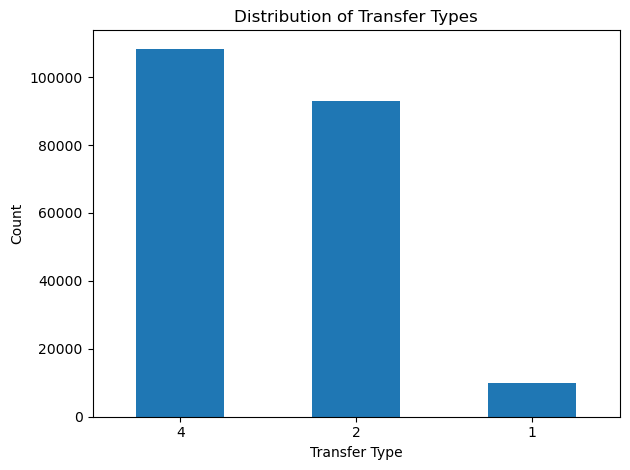

In [20]:
# We plot the distribution of transfer types to understand the prevalence of different transfer conditions
transfers["transfer_type"].value_counts().plot(kind="bar")
plt.title("Distribution of Transfer Types")
plt.xlabel("Transfer Type")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Transfer time analysis

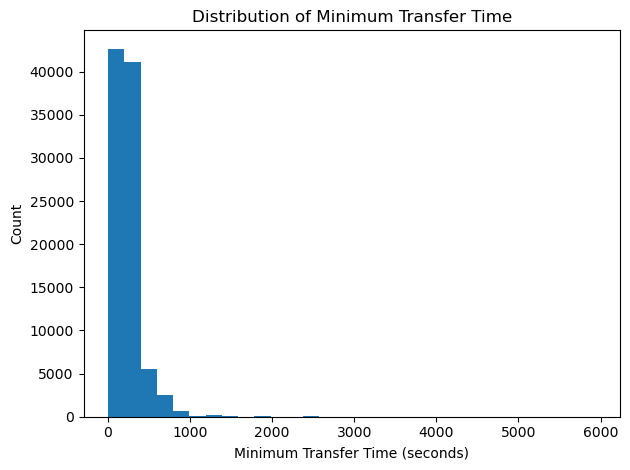

In [21]:
# We plot the distribution of transfer time to understand how long passengers typically have to wait for a transfer
transfers["min_transfer_time"].plot(kind="hist", bins=30)
plt.title("Distribution of Minimum Transfer Time")
plt.xlabel("Minimum Transfer Time (seconds)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

### Calendar

In [22]:
calendar.head()

,service_id,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date
0,TA,1,1,1,1,1,1,1,20251214,20261212
1,TA+00100,0,0,0,0,1,0,1,20251214,20261212
2,TA+00300,0,0,0,0,0,1,1,20251214,20261212
3,TA+00320,0,0,0,0,0,0,1,20251214,20261212
4,TA+00500,0,0,0,0,1,1,1,20251214,20261212


The calendar dataframe contains information about the service availability for each service_id, which can be used to determine on which days certain routes operate. It includes:
- `service_id`: Unique identifier for each service schedule.
- `monday` to `sunday`: Binary indicators (1 or 0) for whether the service operates on each day of the week.
- `start_date` and `end_date`: The date range during which the service is active.


### Range of service

In [23]:
# Showing the range of service dates to understand the coverage of the timetable
print(f"Calendar covers from {calendar['start_date'].min()} to {calendar['end_date'].max()}")

Calendar covers from 20251214 to 20261212


### Service days analysis

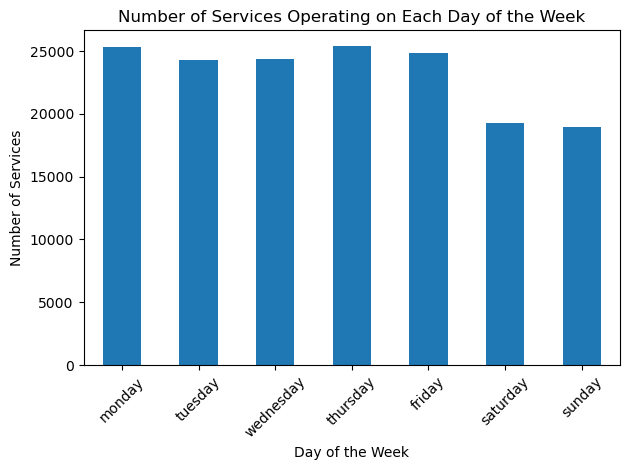

In [24]:
# Plot the distribution of service days to see how many services operate on each day of the week
service_days = calendar[["monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday"]].sum()
service_days.plot(kind="bar")
plt.title("Number of Services Operating on Each Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Services")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Stops where InterCity trains stop

In [15]:
# We look for routes that are InterCity (IC) trains based on their route_category 'IC'
ic_routes = routes[routes['route_category'] == 'IC']
ic_trips = trips[trips['route_id'].isin(ic_routes['route_id'])]

# Get the stop_id where IC trains actually stop
ic_stop_ids = stop_times[stop_times['trip_id'].isin(ic_trips['trip_id'])]['stop_id'].unique()
ic_stops = stops[stops['stop_id'].isin(ic_stop_ids)]

print(f"Number of IC stops identified: {len(ic_stops)}")

Number of IC stops identified: 430


## Connectivity of InterCity (IC) Hubs

In [28]:
# Filter stop_times to include only arrivals/departures at identified IC stops
ic_stop_times = stop_times[stop_times['stop_id'].isin(ic_stop_ids)]

# Calculate the connectivity score by counting the number of IC trains serving each stop
# This represents the total service volume for IC trains over the feed period
connectivity = ic_stop_times.groupby('stop_id').size().reset_index(name='num_trains')

# Merge connectivity scores back with the IC stops dataframe to get station names
ic_hubs_analysis = ic_stops.merge(connectivity, on='stop_id')

# Display the top 5 most connected hubs
print("Top 5 hubs by number of scheduled IC trains over the feed period:")
print(ic_hubs_analysis.sort_values(by='num_trains', ascending=False)[['stop_name', 'num_trains']].head(5))

Top 5 hubs by number of scheduled IC trains over the feed period:
           stop_name  num_trains
391   Lyon Part Dieu        3585
176  Zürich Oerlikon        2812
90            Morges        2799
266       Winterthur        2641
134            Aarau        2574
